# Intel Image Classification - ME592 Assignment

This notebook satisfies Task A requirements:
- Lightweight CNN (~500K params)
- Deeper CNN (~10M params)
- At least two hyperparameter configs per model
- Training/validation curves, confusion matrix, and correct/incorrect examples

Run block-by-block. Keep logs from each run for your presentation later.

## 0) Environment Setup (run in terminal first)

### Conda (recommended for RTX 4070 Super + CUDA)
```bash
conda env create -f environment.yml
conda activate me592-intel-cnn
python -m ipykernel install --user --name me592-intel-cnn --display-name "Python (me592-intel-cnn)"
jupyter lab
```

### Optional local venv
```bash
python -m venv .venv
.venv\\Scripts\\activate
python -m pip install --upgrade pip
pip install -r requirements.txt
jupyter lab
```

> If using venv on Windows, install the correct CUDA PyTorch build from pytorch.org if `torch.cuda.is_available()` is False.

In [ ]:
import os
import json
import random
import time
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8")
sns.set_context("talk")
print("Imports loaded.")

Imports loaded.


C:\Users\mohd7\AppData\Local\miniconda3\envs\me592-intel-cnn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Reproducibility + hardware setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version (torch): {torch.version.cuda}")
else:
    print("CUDA not available. Check environment and PyTorch install.")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER
CUDA version (torch): 12.1


## 1) Dataset Configuration

Update `DATASET_ROOT` to your local folder. This code auto-detects common Intel dataset layouts.

In [ ]:
DATASET_ROOT = Path("./")  # <-- CHANGE if needed, e.g. Path("./intel-image-classification")
EXPECTED_CLASSES = {"buildings", "forest", "glacier", "mountain", "sea", "street"}

def has_class_subdirs(folder: Path) -> bool:
    if not folder.exists() or not folder.is_dir():
        return False
    subdirs = {p.name.lower() for p in folder.iterdir() if p.is_dir()}
    return EXPECTED_CLASSES.issubset(subdirs)

def find_split_dir(root: Path, split_keywords: List[str]) -> Path:
    # Prioritize exact keyword folder names first
    for key in split_keywords:
        for p in root.rglob(key):
            if p.is_dir() and has_class_subdirs(p):
                return p

    # Fallback: any folder with class subdirectories
    for p in root.rglob("*"):
        if p.is_dir() and has_class_subdirs(p):
            return p

    raise FileNotFoundError(
        f"Could not find dataset split under {root.resolve()} with expected class folders."
    )

train_dir = find_split_dir(DATASET_ROOT, ["seg_train", "train"])
val_dir = find_split_dir(DATASET_ROOT, ["seg_test", "test", "val", "valid"])

print(f"Train dir: {train_dir}")
print(f"Val/Test dir: {val_dir}")

Train dir: seg_train\seg_train
Val/Test dir: seg_test\seg_test


In [ ]:
# Global training knobs (edit these often)
IMG_SIZE = 150
NUM_WORKERS = min(8, os.cpu_count() or 2)
PIN_MEMORY = DEVICE.type == "cuda"
BATCH_SIZE_DEFAULT = 64
EPOCHS_LIGHT = 12
EPOCHS_DEEP = 10
FAST_DEV_RUN = False  # set True for quick pipeline test

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds = datasets.ImageFolder(val_dir, transform=val_tfms)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")
print(f"Train samples: {len(train_ds)} | Val/Test samples: {len(val_ds)}")

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE_DEFAULT,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE_DEFAULT,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("DataLoaders ready.")

Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train samples: 14034 | Val/Test samples: 3000
DataLoaders ready.


In [ ]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.block(x)

class LightCNN(nn.Module):
    """Approx. 0.5M params."""
    def __init__(self, num_classes: int = 6, dropout: float = 0.2):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 384),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(384, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

def build_deep_model(num_classes: int = 6, dropout: float = 0.3) -> nn.Module:
    # ResNet-18 gives around 11M parameters, close to the assignment target.
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )
    return model

light_probe = LightCNN(num_classes)
deep_probe = build_deep_model(num_classes)
print(f"LightCNN params: {count_trainable_params(light_probe):,}")
print(f"Deep ResNet18 params: {count_trainable_params(deep_probe):,}")

LightCNN params: 489,894
Deep ResNet18 params: 11,179,590


In [ ]:
@dataclass
class TrainConfig:
    name: str
    model_type: str  # "light" or "deep"
    epochs: int
    batch_size: int
    lr: float
    optimizer: str  # "adam" or "sgd"
    weight_decay: float
    dropout: float
    momentum: float = 0.9

def make_loaders(batch_size: int) -> Tuple[DataLoader, DataLoader]:
    tr = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    va = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    return tr, va

def build_model(cfg: TrainConfig) -> nn.Module:
    if cfg.model_type == "light":
        return LightCNN(num_classes=num_classes, dropout=cfg.dropout)
    if cfg.model_type == "deep":
        return build_deep_model(num_classes=num_classes, dropout=cfg.dropout)
    raise ValueError(f"Unknown model_type: {cfg.model_type}")

def build_optimizer(cfg: TrainConfig, model: nn.Module):
    if cfg.optimizer.lower() == "adam":
        return optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    if cfg.optimizer.lower() == "sgd":
        return optim.SGD(
            model.parameters(),
            lr=cfg.lr,
            momentum=cfg.momentum,
            weight_decay=cfg.weight_decay,
        )
    raise ValueError(f"Unknown optimizer: {cfg.optimizer}")

def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss, total_correct, total_count = 0.0, 0, 0
    loop = tqdm(loader, leave=False)

    for x, y in loop:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total_count += x.size(0)

        loop.set_description("train" if is_train else "valid")
        loop.set_postfix(loss=total_loss / total_count, acc=total_correct / total_count)

        if FAST_DEV_RUN and total_count >= 512:
            break

    return total_loss / total_count, total_correct / total_count

def train_model(cfg: TrainConfig):
    print("=" * 90)
    print(f"Starting experiment: {cfg.name}")
    print(cfg)

    model = build_model(cfg).to(DEVICE)
    print(f"Trainable params: {count_trainable_params(model):,}")

    tr_loader, va_loader = make_loaders(cfg.batch_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(cfg, model)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    best_state = None
    best_val_acc = -1.0

    start_time = time.time()
    for epoch in range(1, cfg.epochs + 1):
        epoch_start = time.time()
        tr_loss, tr_acc = run_epoch(model, tr_loader, criterion, optimizer=optimizer, scaler=scaler)
        va_loss, va_acc = run_epoch(model, va_loader, criterion, optimizer=None, scaler=None)
        scheduler.step(va_acc)

        current_lr = optimizer.param_groups[0]["lr"]
        history["epoch"].append(epoch)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(current_lr)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        epoch_time = time.time() - epoch_start
        elapsed = time.time() - start_time
        print(
            f"[Epoch {epoch:02d}/{cfg.epochs}] "
            f"train_loss={tr_loss:.4f}, train_acc={tr_acc:.4f}, "
            f"val_loss={va_loss:.4f}, val_acc={va_acc:.4f}, lr={current_lr:.2e}, "
            f"epoch_time={epoch_time:.1f}s, elapsed={elapsed/60:.1f}m"
        )

    model.load_state_dict(best_state)
    print(f"Best val_acc for {cfg.name}: {best_val_acc:.4f}")

    return model, history, best_val_acc

def evaluate_with_predictions(model: nn.Module, loader: DataLoader):
    model.eval()
    y_true, y_pred = [], []
    all_probs = []
    idx_offset = 0
    sample_indices = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Collecting predictions", leave=False):
            x = x.to(DEVICE, non_blocking=True)
            logits = model(x)
            probs = logits.softmax(dim=1).cpu()
            preds = probs.argmax(dim=1)

            y_true.extend(y.numpy().tolist())
            y_pred.extend(preds.numpy().tolist())
            all_probs.extend(probs.numpy().tolist())

            batch_size = y.shape[0]
            sample_indices.extend(list(range(idx_offset, idx_offset + batch_size)))
            idx_offset += batch_size

    return np.array(y_true), np.array(y_pred), np.array(all_probs), np.array(sample_indices)

## 2) Hyperparameter Experiments

You must run at least two configs per model. Start with these and then tune:
- `lr`: try `1e-3`, `3e-4`, `1e-4`
- `optimizer`: `adam` vs `sgd`
- `dropout`: `0.2` vs `0.5`
- `batch_size`: `32`, `64`, `96` (depends on VRAM)

In [ ]:
light_experiments = [
    TrainConfig(
        name="light_adam_lr1e3_do02",
        model_type="light",
        epochs=EPOCHS_LIGHT,
        batch_size=64,
        lr=1e-3,
        optimizer="adam",
        weight_decay=1e-4,
        dropout=0.2,
    ),
    TrainConfig(
        name="light_sgd_lr3e4_do05",
        model_type="light",
        epochs=EPOCHS_LIGHT,
        batch_size=64,
        lr=3e-4,
        optimizer="sgd",
        weight_decay=1e-4,
        dropout=0.5,
        momentum=0.9,
    ),
]

deep_experiments = [
    TrainConfig(
        name="deep_adam_lr1e4_do03",
        model_type="deep",
        epochs=EPOCHS_DEEP,
        batch_size=48,
        lr=1e-4,
        optimizer="adam",
        weight_decay=1e-4,
        dropout=0.3,
    ),
    TrainConfig(
        name="deep_sgd_lr3e4_do05",
        model_type="deep",
        epochs=EPOCHS_DEEP,
        batch_size=48,
        lr=3e-4,
        optimizer="sgd",
        weight_decay=5e-4,
        dropout=0.5,
        momentum=0.9,
    ),
]

all_experiments = light_experiments + deep_experiments
print("Experiments prepared:")
for c in all_experiments:
    print(" -", c.name)

Experiments prepared:
 - light_adam_lr1e3_do02
 - light_sgd_lr3e4_do05
 - deep_adam_lr1e4_do03
 - deep_sgd_lr3e4_do05


In [ ]:
# Run all experiments (can take time; this is the core assignment work)
results = {}
best_overall = {"name": None, "val_acc": -1.0, "model": None, "history": None, "cfg": None}

for cfg in all_experiments:
    model, hist, best_val_acc = train_model(cfg)
    results[cfg.name] = {
        "cfg": cfg,
        "history": hist,
        "best_val_acc": best_val_acc,
        "model": model,
    }

    if best_val_acc > best_overall["val_acc"]:
        best_overall = {
            "name": cfg.name,
            "val_acc": best_val_acc,
            "model": model,
            "history": hist,
            "cfg": cfg,
        }

print("\nBest overall experiment:")
print(best_overall["name"], "| val_acc=", round(best_overall["val_acc"], 4))

Starting experiment: light_adam_lr1e3_do02
TrainConfig(name='light_adam_lr1e3_do02', model_type='light', epochs=12, batch_size=64, lr=0.001, optimizer='adam', weight_decay=0.0001, dropout=0.2, momentum=0.9)


C:\Users\mohd7\AppData\Local\Temp\ipykernel_13500\4242138796.py:95: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


Trainable params: 489,894


  0%|                                                                                          | 0/220 [00:00<?, ?it/s]C:\Users\mohd7\AppData\Local\Temp\ipykernel_13500\4242138796.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                                                                                                                       

[Epoch 01/12] train_loss=0.9218, train_acc=0.6264, val_loss=0.8232, val_acc=0.6967, lr=1.00e-03, epoch_time=68.8s, elapsed=1.1m


...

[Epoch 06/10] train_loss=0.2435, train_acc=0.9140, val_loss=0.2025, val_acc=0.9263, lr=3.00e-04, epoch_time=62.8s, elapsed=6.3m


[Epoch 07/10] train_loss=0.2299, train_acc=0.9192, val_loss=0.1893, val_acc=0.9323, lr=3.00e-04, epoch_time=62.5s, elapsed=7.3m


[Epoch 08/10] train_loss=0.2217, train_acc=0.9201, val_loss=0.1858, val_acc=0.9310, lr=3.00e-04, epoch_time=62.6s, elapsed=8.3m


[Epoch 09/10] train_loss=0.2111, train_acc=0.9229, val_loss=0.1796, val_acc=0.9363, lr=3.00e-04, epoch_time=62.6s, elapsed=9.4m


[Epoch 10/10] train_loss=0.2011, train_acc=0.9273, val_loss=0.1774, val_acc=0.9327, lr=3.00e-04, epoch_time=62.5s, elapsed=10.4m
Best val_acc for deep_sgd_lr3e4_do05: 0.9363

Best overall experiment:
deep_adam_lr1e4_do03 | val_acc= 0.9387


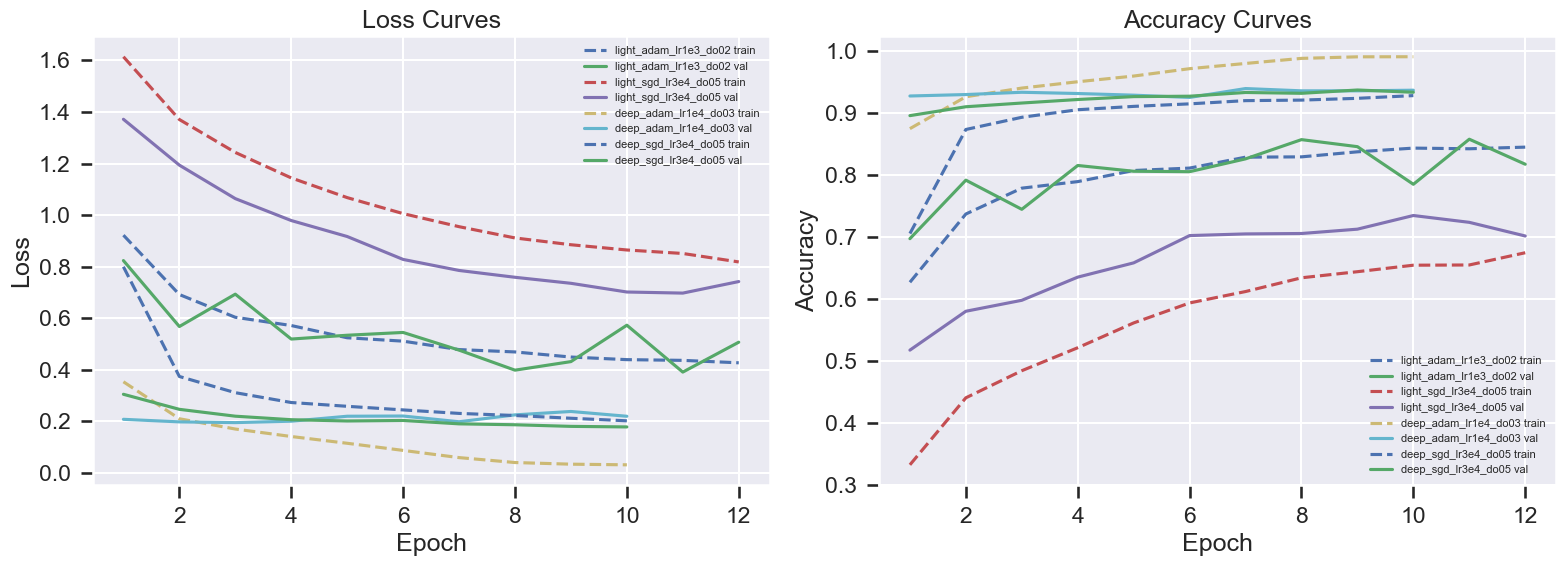

In [ ]:
def plot_histories(results_dict: Dict[str, Dict]):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for name, payload in results_dict.items():
        h = payload["history"]
        axes[0].plot(h["epoch"], h["train_loss"], linestyle="--", label=f"{name} train")
        axes[0].plot(h["epoch"], h["val_loss"], label=f"{name} val")

        axes[1].plot(h["epoch"], h["train_acc"], linestyle="--", label=f"{name} train")
        axes[1].plot(h["epoch"], h["val_acc"], label=f"{name} val")

    axes[0].set_title("Loss Curves")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=8)

    axes[1].set_title("Accuracy Curves")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_histories(results)

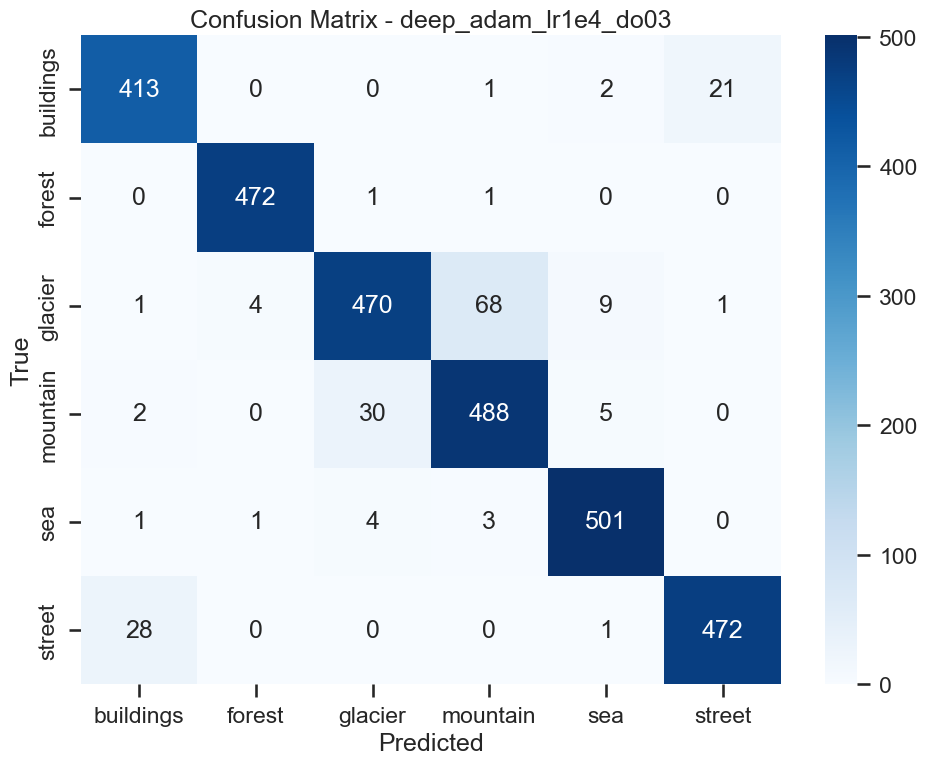

              precision    recall  f1-score   support

   buildings     0.9281    0.9451    0.9365       437
      forest     0.9895    0.9958    0.9926       474
     glacier     0.9307    0.8499    0.8885       553
    mountain     0.8699    0.9295    0.8987       525
         sea     0.9672    0.9824    0.9747       510
      street     0.9555    0.9421    0.9487       501

    accuracy                         0.9387      3000
   macro avg     0.9401    0.9408    0.9400      3000
weighted avg     0.9393    0.9387    0.9384      3000



In [ ]:
# Confusion matrix + report for best model
best_model = best_overall["model"]
best_cfg = best_overall["cfg"]
best_loader = DataLoader(
    val_ds,
    batch_size=best_cfg.batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

y_true, y_pred, y_prob, sample_indices = evaluate_with_predictions(best_model, best_loader)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix - {best_overall['name']}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

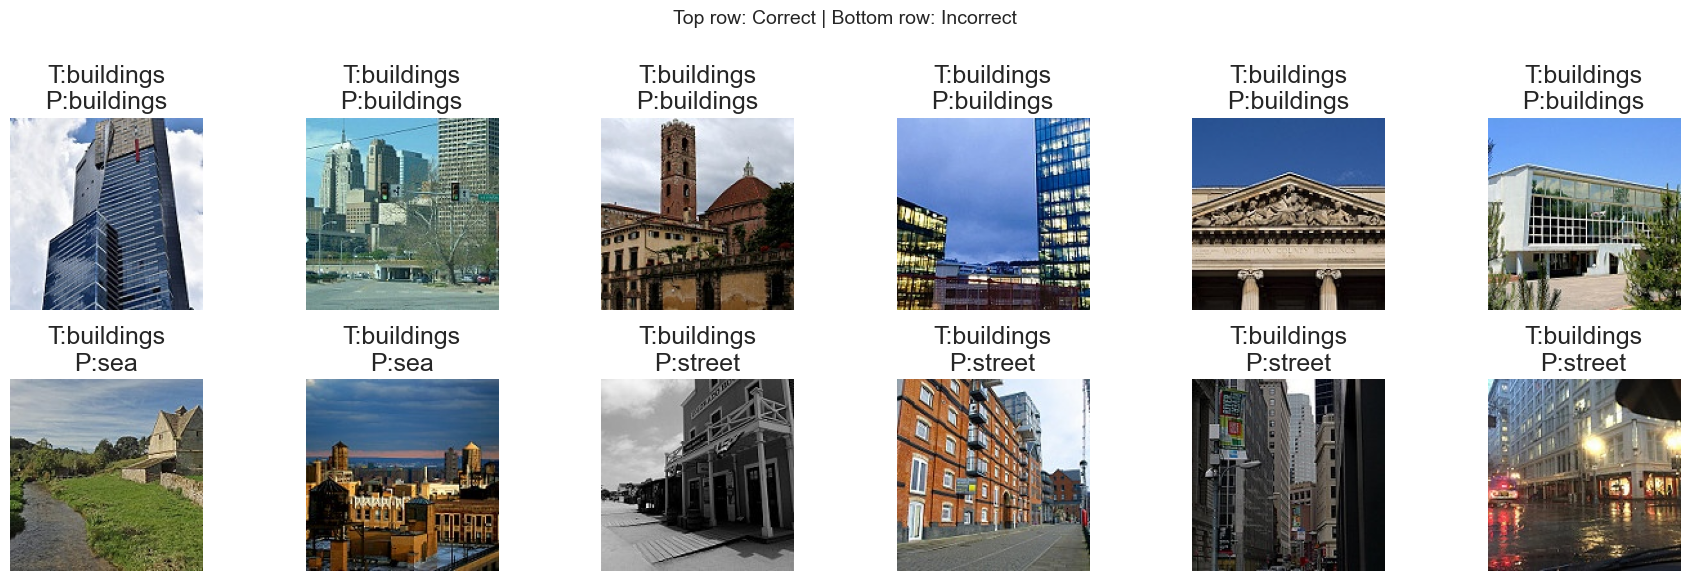

In [ ]:
def denorm_image(t: torch.Tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    x = t.cpu() * std + mean
    return x.clamp(0, 1)

def show_correct_incorrect_examples(model, dataset, n_each=6):
    model.eval()
    correct, incorrect = [], []

    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    start_idx = 0

    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="Finding examples", leave=False):
            logits = model(xb.to(DEVICE, non_blocking=True))
            preds = logits.argmax(dim=1).cpu()

            for i in range(len(yb)):
                rec = {
                    "img": xb[i],
                    "true": int(yb[i]),
                    "pred": int(preds[i]),
                    "idx": start_idx + i,
                }
                if rec["pred"] == rec["true"] and len(correct) < n_each:
                    correct.append(rec)
                elif rec["pred"] != rec["true"] and len(incorrect) < n_each:
                    incorrect.append(rec)

                if len(correct) >= n_each and len(incorrect) >= n_each:
                    break

            start_idx += len(yb)
            if len(correct) >= n_each and len(incorrect) >= n_each:
                break

    fig, axes = plt.subplots(2, n_each, figsize=(3 * n_each, 6))
    fig.suptitle("Top row: Correct | Bottom row: Incorrect", fontsize=14)

    for col in range(n_each):
        if col < len(correct):
            c = correct[col]
            axes[0, col].imshow(np.transpose(denorm_image(c["img"]).numpy(), (1, 2, 0)))
            axes[0, col].set_title(f"T:{class_names[c['true']]}\nP:{class_names[c['pred']]}")
        axes[0, col].axis("off")

        if col < len(incorrect):
            ic = incorrect[col]
            axes[1, col].imshow(np.transpose(denorm_image(ic["img"]).numpy(), (1, 2, 0)))
            axes[1, col].set_title(f"T:{class_names[ic['true']]}\nP:{class_names[ic['pred']]}")
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.show()

show_correct_incorrect_examples(best_model, val_ds, n_each=6)

In [ ]:
# Save experiment artifacts (useful for presentation)
out_dir = Path("./assignment_outputs")
out_dir.mkdir(parents=True, exist_ok=True)

summary_rows = []
for name, payload in results.items():
    cfg = payload["cfg"]
    h = payload["history"]
    summary_rows.append({
        "name": name,
        "model_type": cfg.model_type,
        "optimizer": cfg.optimizer,
        "lr": cfg.lr,
        "dropout": cfg.dropout,
        "batch_size": cfg.batch_size,
        "best_val_acc": payload["best_val_acc"],
        "final_train_acc": h["train_acc"][-1],
        "final_val_acc": h["val_acc"][-1],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("best_val_acc", ascending=False)
summary_path = out_dir / "experiment_summary.csv"
summary_df.to_csv(summary_path, index=False)

history_path = out_dir / "all_histories.json"
serializable_histories = {k: v["history"] for k, v in results.items()}
history_path.write_text(json.dumps(serializable_histories, indent=2))

best_model_path = out_dir / f"best_model_{best_overall['name']}.pt"
torch.save(best_model.state_dict(), best_model_path)

print("Saved:")
print(" -", summary_path)
print(" -", history_path)
print(" -", best_model_path)
display(summary_df)

Saved:
 - assignment_outputs\experiment_summary.csv
 - assignment_outputs\all_histories.json
 - assignment_outputs\best_model_deep_adam_lr1e4_do03.pt


,name,model_type,optimizer,lr,dropout,batch_size,best_val_acc,final_train_acc,final_val_acc
2,deep_adam_lr1e4_do03,deep,adam,0.0001,0.3,48,0.938667,0.989953,0.936000
3,deep_sgd_lr3e4_do05,deep,sgd,0.0003,0.5,48,0.936333,0.927319,0.932667
0,light_adam_lr1e3_do02,light,adam,0.0010,0.2,64,0.857000,0.844235,0.816667
1,light_sgd_lr3e4_do05,light,sgd,0.0003,0.5,64,0.734000,0.674006,0.701000


## 3) Tuning Guide (what to change first)

1. **If overfitting** (train acc high, val acc low): increase `dropout`, stronger augmentation, higher weight decay.
2. **If underfitting** (both low): train longer, lower regularization, increase model capacity.
3. **If unstable loss**: lower `lr` by 2-3x, or switch Adam -> SGD with momentum.
4. **If GPU memory issue**: reduce `batch_size` (e.g., 48 -> 32).
5. **For better deep model accuracy**: freeze backbone for 2-3 epochs, then unfreeze and fine-tune with lower lr.

Run the three additional experiments below and include them in your final comparison table for submission.

In [ ]:
# Extra high-value tuning experiments (requested additions)
extra_experiments = [
    TrainConfig(
        name="deep_adam_lr3e4_do03_ep12",
        model_type="deep",
        epochs=12,
        batch_size=48,
        lr=3e-4,
        optimizer="adam",
        weight_decay=1e-4,
        dropout=0.3,
    ),
    TrainConfig(
        name="deep_adam_lr1e4_do02_ep14",
        model_type="deep",
        epochs=14,
        batch_size=48,
        lr=1e-4,
        optimizer="adam",
        weight_decay=1e-4,
        dropout=0.2,
    ),
    TrainConfig(
        name="light_adam_lr5e4_do03_ep14",
        model_type="light",
        epochs=14,
        batch_size=64,
        lr=5e-4,
        optimizer="adam",
        weight_decay=1e-4,
        dropout=0.3,
    ),
]

print("Extra experiments prepared:")
for cfg in extra_experiments:
    print(" -", cfg.name)

Extra experiments prepared:
 - deep_adam_lr3e4_do03_ep12
 - deep_adam_lr1e4_do02_ep14
 - light_adam_lr5e4_do03_ep14


In [ ]:
# Run extra experiments and merge with existing results
extra_results = {}

for cfg in extra_experiments:
    model, hist, best_val_acc = train_model(cfg)
    payload = {
        "cfg": cfg,
        "history": hist,
        "best_val_acc": best_val_acc,
        "model": model,
    }
    extra_results[cfg.name] = payload
    results[cfg.name] = payload

    if best_val_acc > best_overall["val_acc"]:
        best_overall = {
            "name": cfg.name,
            "val_acc": best_val_acc,
            "model": model,
            "history": hist,
            "cfg": cfg,
        }

print("\nExtra runs complete.")
print("Current best overall:")
print(best_overall["name"], "| val_acc=", round(best_overall["val_acc"], 4))

C:\Users\mohd7\AppData\Local\Temp\ipykernel_13500\4242138796.py:95: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


Starting experiment: deep_adam_lr3e4_do03_ep12
TrainConfig(name='deep_adam_lr3e4_do03_ep12', model_type='deep', epochs=12, batch_size=48, lr=0.0003, optimizer='adam', weight_decay=0.0001, dropout=0.3, momentum=0.9)
Trainable params: 11,179,590


  0%|                                                                                          | 0/293 [00:00<?, ?it/s]C:\Users\mohd7\AppData\Local\Temp\ipykernel_13500\4242138796.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                                                                                                                       

[Epoch 01/12] train_loss=0.3628, train_acc=0.8765, val_loss=0.2519, val_acc=0.9080, lr=3.00e-04, epoch_time=63.1s, elapsed=1.1m


[Epoch 02/12] train_loss=0.2527, train_acc=0.9129, val_loss=0.2366, val_acc=0.9150, lr=3.00e-04, epoch_time=62.9s, elapsed=2.1m


...

[Epoch 10/14] train_loss=0.4626, train_acc=0.8334, val_loss=0.4088, val_acc=0.8583, lr=5.00e-04, epoch_time=62.3s, elapsed=10.4m


[Epoch 11/14] train_loss=0.4485, train_acc=0.8376, val_loss=0.5167, val_acc=0.8010, lr=5.00e-04, epoch_time=62.4s, elapsed=11.4m


[Epoch 12/14] train_loss=0.4349, train_acc=0.8442, val_loss=0.3939, val_acc=0.8627, lr=5.00e-04, epoch_time=62.0s, elapsed=12.4m


[Epoch 13/14] train_loss=0.4222, train_acc=0.8463, val_loss=0.4576, val_acc=0.8287, lr=5.00e-04, epoch_time=62.2s, elapsed=13.5m


[Epoch 14/14] train_loss=0.4255, train_acc=0.8477, val_loss=0.4210, val_acc=0.8487, lr=5.00e-04, epoch_time=62.0s, elapsed=14.5m
Best val_acc for light_adam_lr5e4_do03_ep14: 0.8627

Extra runs complete.
Current best overall:
deep_adam_lr1e4_do02_ep14 | val_acc= 0.942


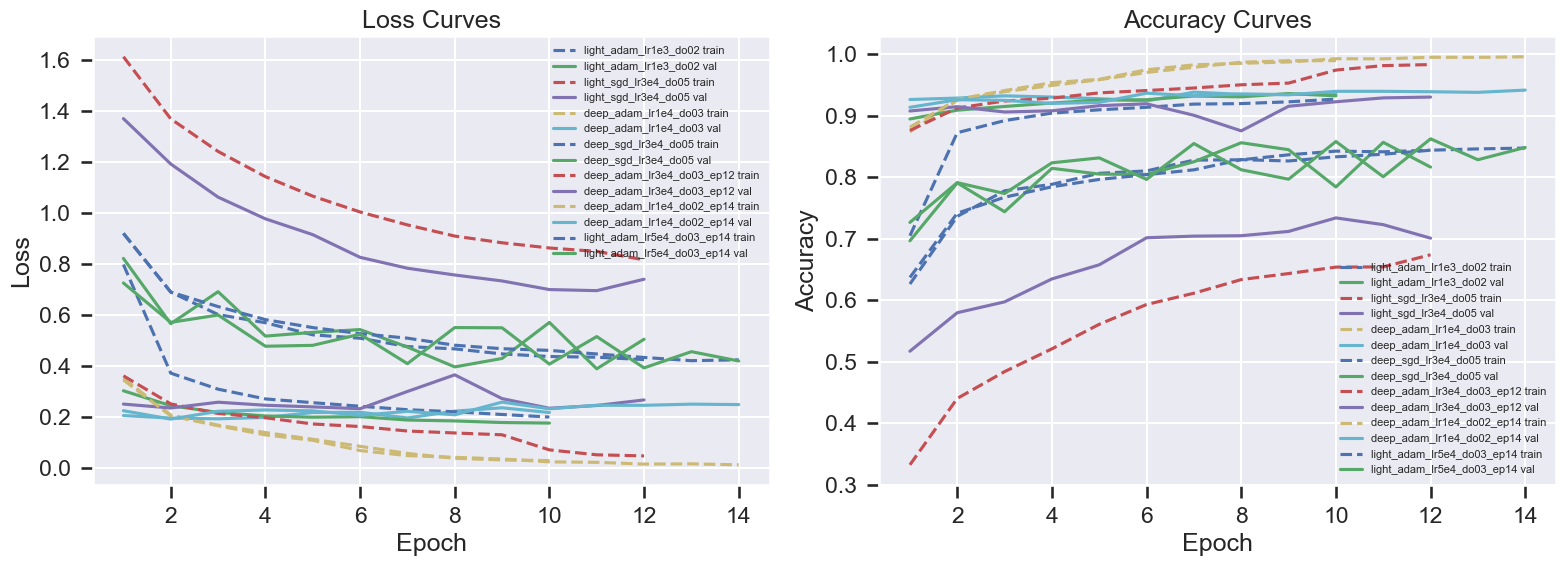

Saved updated tuning artifacts:
 - assignment_outputs\experiment_summary_after_tuning.csv
 - assignment_outputs\all_histories_after_tuning.json
 - assignment_outputs\best_model_after_tuning_deep_adam_lr1e4_do02_ep14.pt


,name,model_type,optimizer,lr,dropout,batch_size,epochs,best_val_acc,final_train_acc,final_val_acc
5,deep_adam_lr1e4_do02_ep14,deep,adam,0.0001,0.2,48,14,0.942000,0.996295,0.942000
2,deep_adam_lr1e4_do03,deep,adam,0.0001,0.3,48,10,0.938667,0.989953,0.936000
3,deep_sgd_lr3e4_do05,deep,sgd,0.0003,0.5,48,10,0.936333,0.927319,0.932667
4,deep_adam_lr3e4_do03_ep12,deep,adam,0.0003,0.3,48,12,0.930667,0.983540,0.930667
6,light_adam_lr5e4_do03_ep14,light,adam,0.0005,0.3,64,14,0.862667,0.847656,0.848667
0,light_adam_lr1e3_do02,light,adam,0.0010,0.2,64,12,0.857000,0.844235,0.816667
1,light_sgd_lr3e4_do05,light,sgd,0.0003,0.5,64,12,0.734000,0.674006,0.701000


In [ ]:
# Re-plot and re-save artifacts after extra tuning runs
plot_histories(results)

out_dir = Path("./assignment_outputs")
out_dir.mkdir(parents=True, exist_ok=True)

summary_rows = []
for name, payload in results.items():
    cfg = payload["cfg"]
    h = payload["history"]
    summary_rows.append({
        "name": name,
        "model_type": cfg.model_type,
        "optimizer": cfg.optimizer,
        "lr": cfg.lr,
        "dropout": cfg.dropout,
        "batch_size": cfg.batch_size,
        "epochs": cfg.epochs,
        "best_val_acc": payload["best_val_acc"],
        "final_train_acc": h["train_acc"][-1],
        "final_val_acc": h["val_acc"][-1],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("best_val_acc", ascending=False)
summary_path = out_dir / "experiment_summary_after_tuning.csv"
summary_df.to_csv(summary_path, index=False)

history_path = out_dir / "all_histories_after_tuning.json"
serializable_histories = {k: v["history"] for k, v in results.items()}
history_path.write_text(json.dumps(serializable_histories, indent=2))

best_model = best_overall["model"]
best_model_path = out_dir / f"best_model_after_tuning_{best_overall['name']}.pt"
torch.save(best_model.state_dict(), best_model_path)

print("Saved updated tuning artifacts:")
print(" -", summary_path)
print(" -", history_path)
print(" -", best_model_path)

display(summary_df.head(10))